## 1. Project Overview

Customer churn is an important business problem for subscription-based services such as Netflix. Identifying customers who are likely to discontinue their subscriptions can help businesses understand customer behavior and develop effective retention strategies.

This project focuses on developing a machine learning classification model to predict whether a Netflix customer is likely to churn based on customer demographics, subscription details, engagement behavior, and other available customer attributes.

The project follows an end-to-end machine learning workflow, including data understanding, data quality assessment, exploratory data analysis (EDA), feature engineering, preprocessing, model development, evaluation, and model interpretation.

The primary objective is not only to build an accurate predictive model, but also to understand the factors associated with customer churn and evaluate whether the model provides useful insights for potential customer retention strategies.

 Importing required libraries for Exploratory data Analysis (EDA)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
plt.rcParams["figure.dpi"]=120
rng_seed=42

Loading netflix customer churn dataset

In [2]:
df=pd.read_csv("netflix_customer_churn.csv")

Data Preprocessing

In [3]:
# Ensure numeric columns contains numerical values for numeric analysis
numeric_columns=["age", "watch_hours", "last_login_days",
                 "monthly_fee", "churned", "number_of_profiles",
                 "avg_watch_time_per_day"]

for column in numeric_columns:
    df[column]=pd.to_numeric(df[column], errors="coerce")


#for categorical columns, converting them to 'category' type
categorical_columns=["region", "device", "payment_method", "favorite_genre"]
for column in categorical_columns:
    df[column]=df[column].astype("category")

Dataset shape:

In [4]:
print(f"shape= {df.shape}")
print(f"Number of rows= {df.shape[0]}")
print(f"Number of columns= {df.shape[1]}")


shape= (5000, 14)
Number of rows= 5000
Number of columns= 14


First 5 rows:

In [5]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


Last 5 rows:

In [6]:
df.tail()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


List of all columns


In [7]:
for col in df.columns:
    print(col)

customer_id
age
gender
subscription_type
watch_hours
last_login_days
region
device
monthly_fee
churned
payment_method
number_of_profiles
avg_watch_time_per_day
favorite_genre


Datatypes of each columns

In [8]:
df.dtypes

customer_id                 object
age                          int64
gender                      object
subscription_type           object
watch_hours                float64
last_login_days              int64
region                    category
device                    category
monthly_fee                float64
churned                      int64
payment_method            category
number_of_profiles           int64
avg_watch_time_per_day     float64
favorite_genre            category
dtype: object

Column info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             5000 non-null   object  
 1   age                     5000 non-null   int64   
 2   gender                  5000 non-null   object  
 3   subscription_type       5000 non-null   object  
 4   watch_hours             5000 non-null   float64 
 5   last_login_days         5000 non-null   int64   
 6   region                  5000 non-null   category
 7   device                  5000 non-null   category
 8   monthly_fee             5000 non-null   float64 
 9   churned                 5000 non-null   int64   
 10  payment_method          5000 non-null   category
 11  number_of_profiles      5000 non-null   int64   
 12  avg_watch_time_per_day  5000 non-null   float64 
 13  favorite_genre          5000 non-null   category
dtypes: category(4), float64(

Checking for Null Values

In [10]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

Checking for duplicate rows(or entries)

In [11]:
df.duplicated().sum()

np.int64(0)

Dataset Summary

In [12]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


Exploratory data Analysis (EDA)

In [13]:

def figure():
    plt.tight_layout()
    plt.show()

churn Distribution

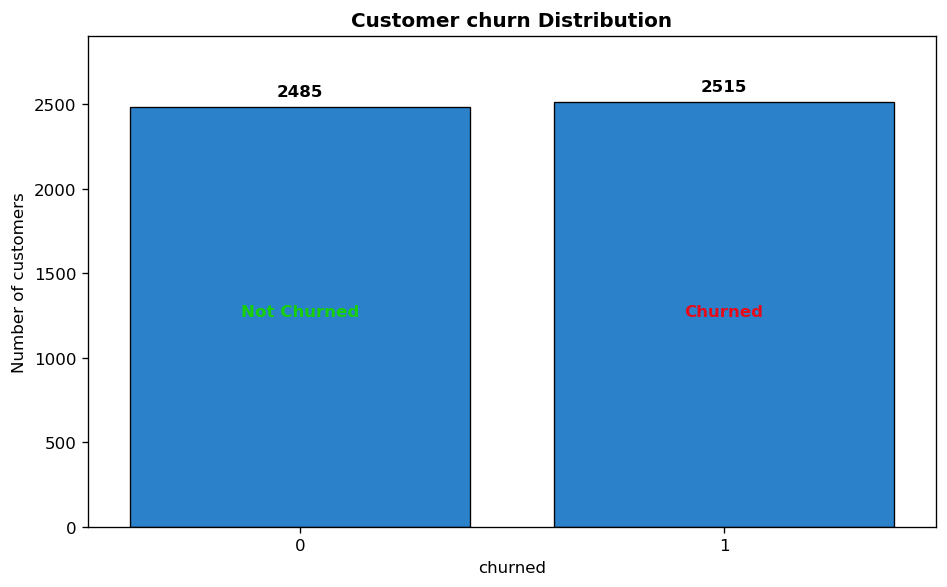

In [14]:
fig,ax=plt.subplots(figsize=(8,5))
sns.countplot(data=df, x="churned", color="#1085e5", edgecolor="black", linewidth=0.8)

ax.set_title("Customer churn Distribution", weight="bold")
ax.set_ylabel("Number of customers")
ax.set_ylim(0, ax.get_ylim()[1]*1.1)
plt.annotate("Not Churned", xy=(0,1250), ha="center", color="#18d007", weight="bold")
plt.annotate("Churned", xy=(1,1250), ha="center", color="#e70a19", weight="bold")

for container in ax.containers:
    ax.bar_label(container, padding=5, weight="bold")
figure()

Wathc Hour distribution

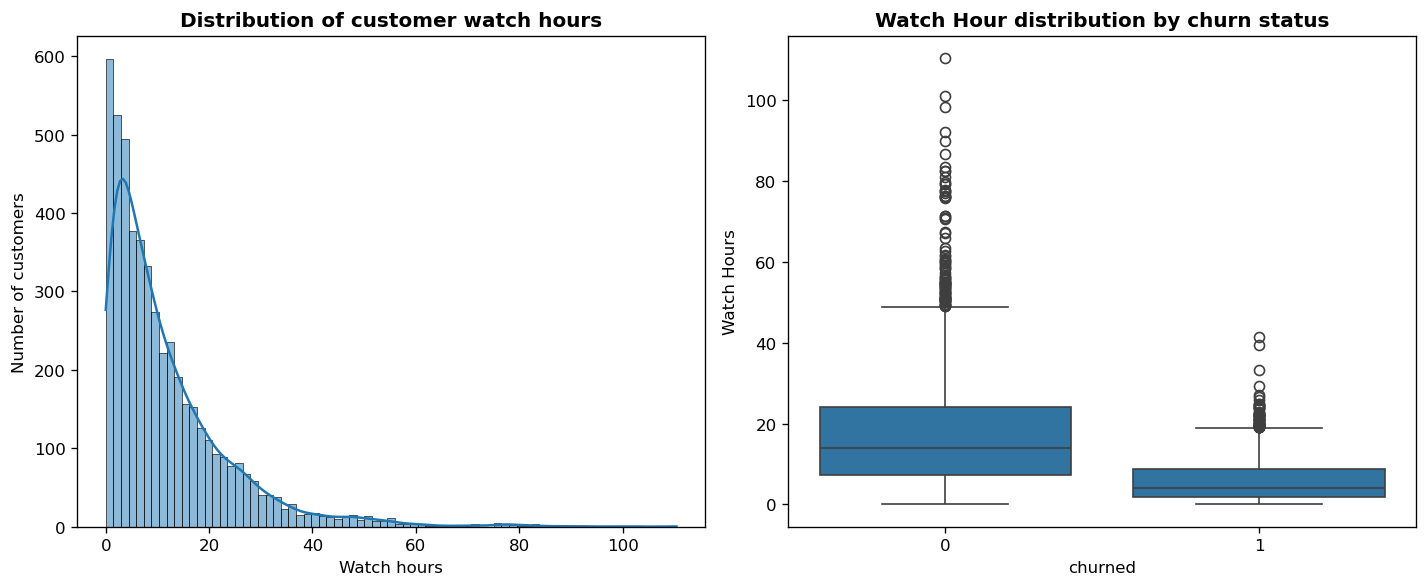

In [15]:
fig, ax=plt.subplots(1,2, figsize=(12,5))

sns.histplot(data=df, x="watch_hours", kde=True, ax=ax[0])
ax[0].set_title("Distribution of customer watch hours", weight="bold")
ax[0].set_xlabel("Watch hours")
ax[0].set_ylabel("Number of customers")

sns.boxplot(data=df,
            x="churned",
            y="watch_hours")
ax[1].set_title("Watch Hour distribution by churn status", weight="bold")
ax[1].set_ylabel("Watch Hours")
figure()

Daily average watch time VS Watch hours by Churn status

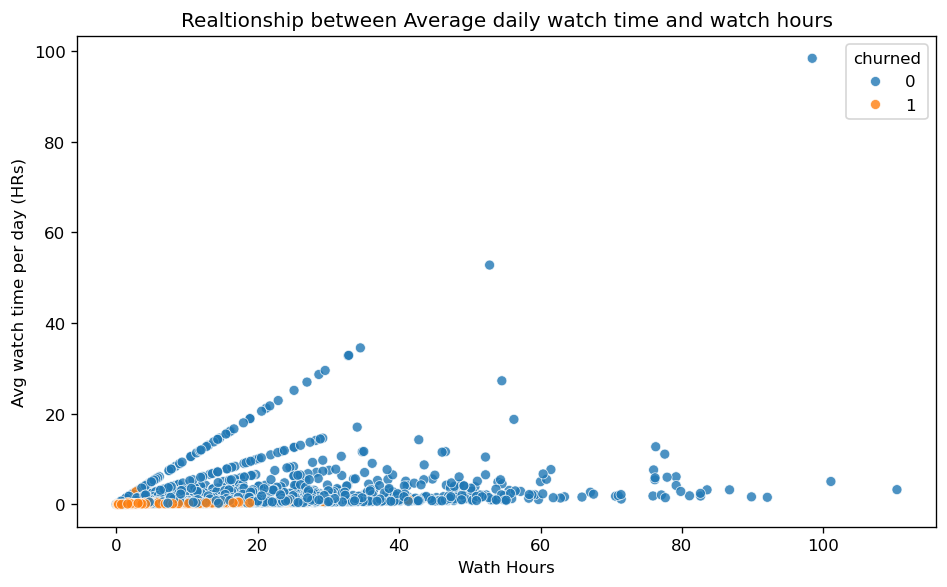

In [16]:
fig,ax= plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x="watch_hours",
                y="avg_watch_time_per_day",
                hue="churned", alpha=0.8)
ax.set_title("Realtionship between Average daily watch time and watch hours")
ax.set_xlabel("Wath Hours")
ax.set_ylabel("Avg watch time per day (HRs)")
figure()

Churn comparison

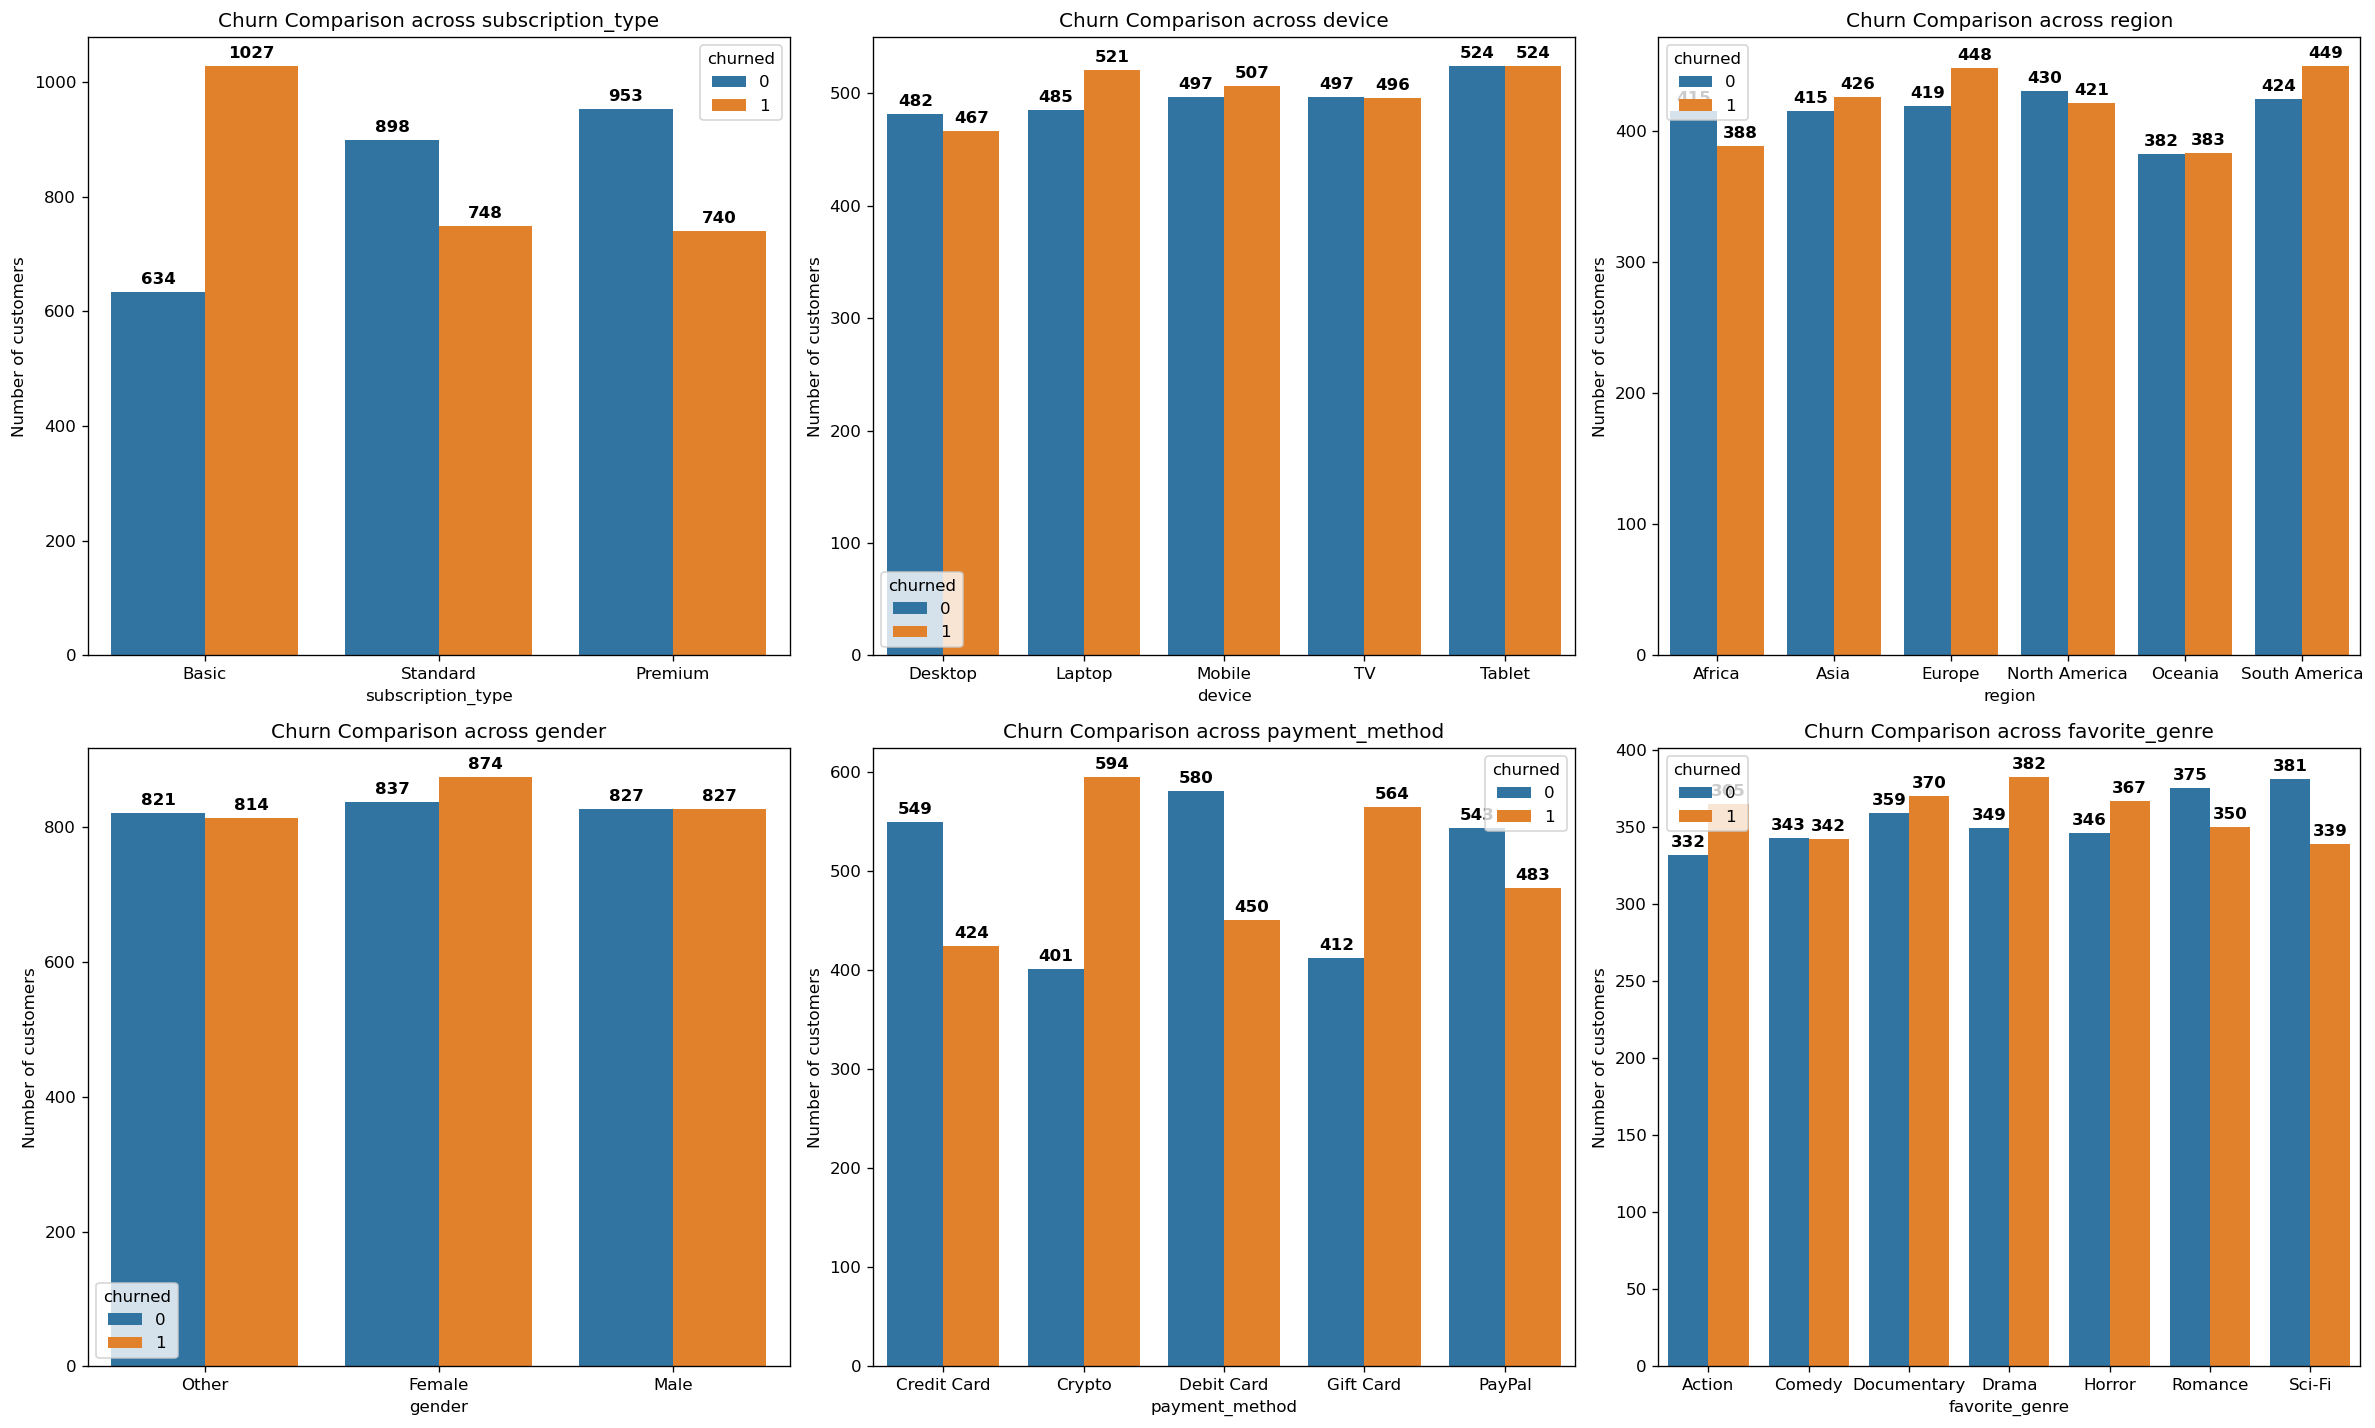

In [17]:
fig, ax=plt.subplots(2,3,figsize=(20,12))
feature=[["subscription_type", "device", "region"],
         ["gender", "payment_method", "favorite_genre"]]

for i in range(2):
    for j in range(3):
        sns.countplot(data=df, x=feature[i][j], hue="churned", ax=ax[i,j])
        ax[i,j].set_title(f"Churn Comparison across {feature[i][j]}")
        ax[i,j].set_ylabel("Number of customers")
        for container in ax[i,j].containers:
            ax[i,j].bar_label(container, padding=3, weight="bold")


figure()

Watch Engagement by Gender


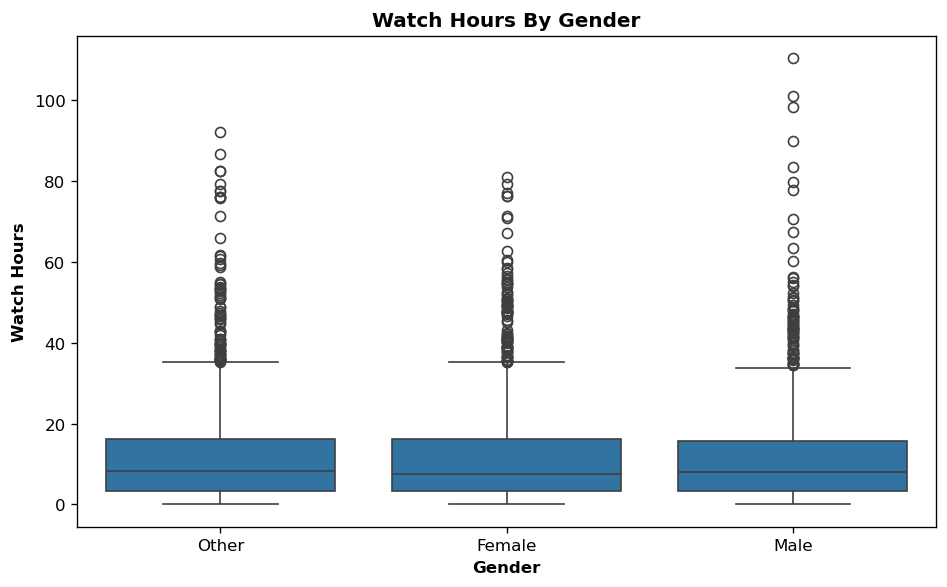

In [18]:
fig,ax=plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="gender", y="watch_hours")
ax.set_title("Watch Hours By Gender", weight="bold")
ax.set_ylabel("Watch Hours", weight="bold")
ax.set_xlabel("Gender", weight="bold")
figure()

Total number of customers by Gender

Text(0.5, 1.0, 'Customer Gender Distribution')

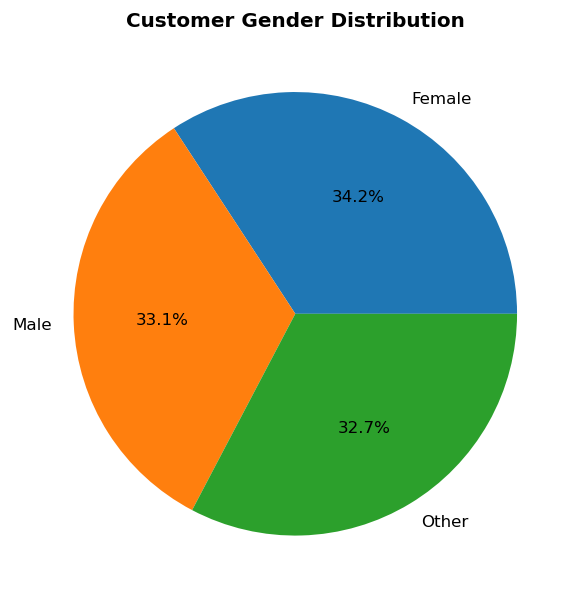

In [19]:
gender_count=df["gender"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_count,
        labels= gender_count.index,
        autopct="%1.1f%%")

plt.title("Customer Gender Distribution", fontsize=12, weight="bold")

Watch hours against Age and Number of profile counts

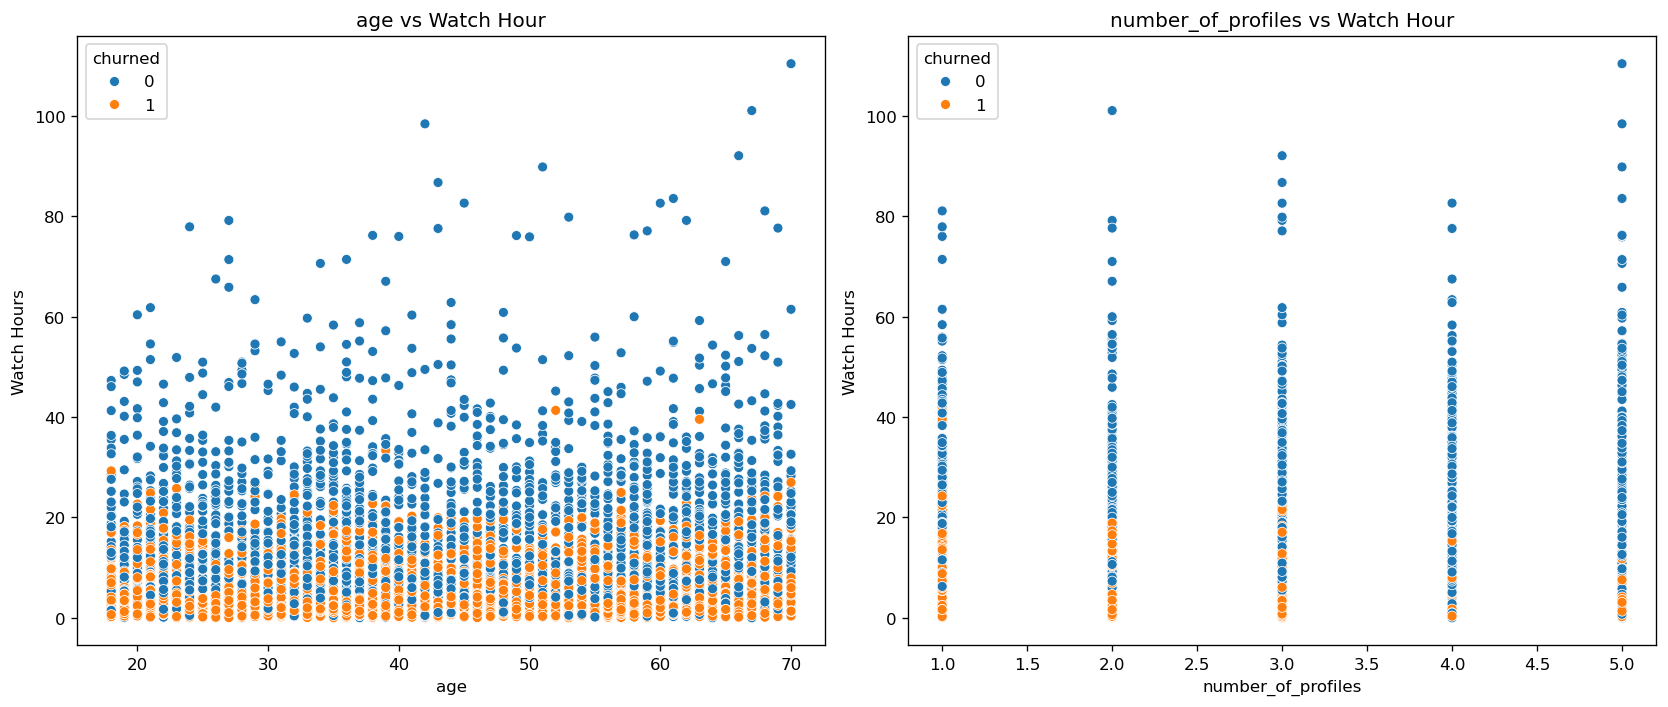

In [20]:
FEATURE=["age", "number_of_profiles"]

fig,ax=plt.subplots(1,2, figsize=(14,6))

for i in range(2):
    sns.scatterplot(data=df, x=FEATURE[i], y="watch_hours", hue="churned", ax=ax[i])
    ax[i].set_title(f"{FEATURE[i]} vs Watch Hour")
    ax[i].set_xlabel(FEATURE[i])
    ax[i].set_ylabel("Watch Hours")
figure()

Churn metrics heatmap

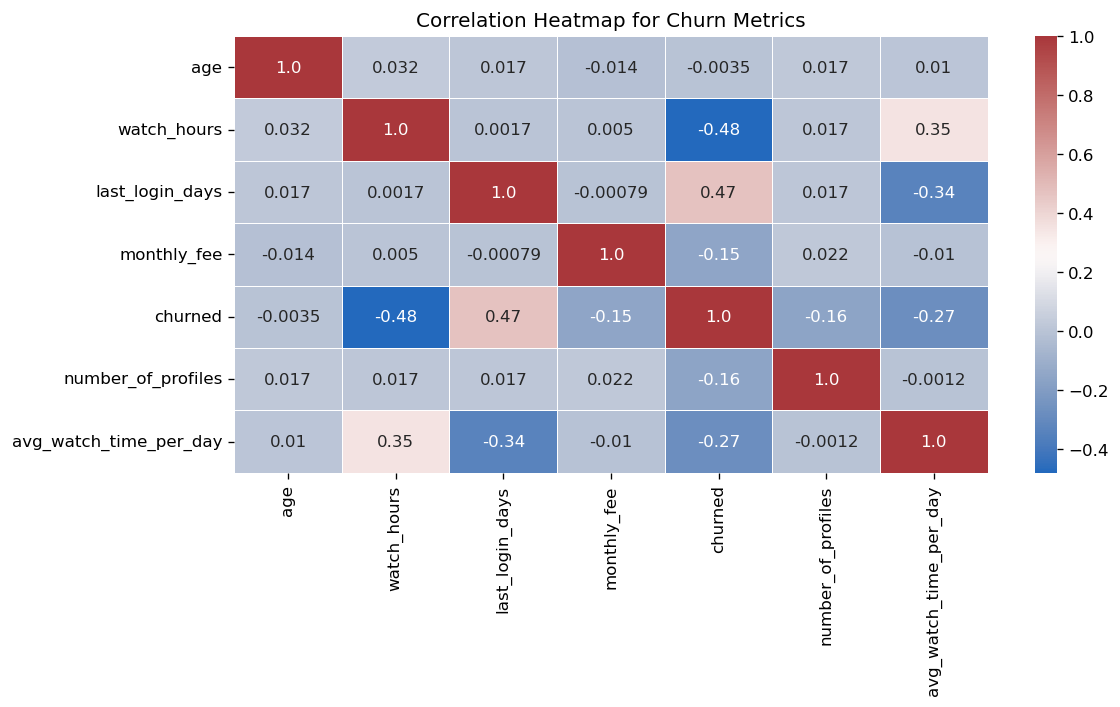

In [21]:
plt.figure(figsize=(10,6))
corr=df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2", cmap="vlag", linewidth=0.5)
plt.title("Correlation Heatmap for Churn Metrics")
figure()

## Model Training

Importing required libraries

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

Feature and target selection

In [23]:
x = df.drop(columns=["customer_id", "churned"])
y = df["churned"]

Separation of Numerical and Categorical columns

In [24]:
num_cols= x.select_dtypes(include="number").columns
cat_cols=x.select_dtypes(include=["object", "category"]).columns
columns_df=pd.DataFrame({"Numerical": num_cols,
                         "Categorical": cat_cols})
columns_df

,Numerical,Categorical
0,age,gender
1,watch_hours,subscription_type
2,last_login_days,region
3,monthly_fee,device
4,number_of_profiles,payment_method
5,avg_watch_time_per_day,favorite_genre


Prepare numerical & categorical features

In [25]:
numerical_pipeline= Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline= Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Combine both numerical and categorical features


In [26]:
preprocessor= ColumnTransformer([
    ("num", numerical_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])


Data spliting for training and testing

In [27]:
x_train, x_test, y_train, y_test=train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Total number of Target=0 in y_train =  {(y_train.values==0).sum()}")
print(f"Total number of Target=1 in y_train =  {(y_train.values==1).sum()}")

Total number of Target=0 in y_train =  1988
Total number of Target=1 in y_train =  2012


 Creating Classification Model

In [28]:
model= Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])


Model Training

In [29]:
model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Predictions

In [30]:
predictions=model.predict(x_test)

Model Evaluation

In [31]:
evaluation_scores=[]
metrics=[accuracy_score, precision_score, f1_score, recall_score]
for metric in metrics:
    score=metric(y_test, predictions)
    evaluation_scores.append({
        "Metric":metric.__name__,
        "Raw_score":score,
        "Score":f"{score*100:.2f}%"
    })
evaluations_df=pd.DataFrame(evaluation_scores)
evaluations_df=evaluations_df.sort_values(by="Raw_score", ascending=False)
evaluations_df=evaluations_df.drop(columns="Raw_score").reset_index(drop=True)
evaluations_df

,Metric,Score
0,recall_score,90.46%
1,f1_score,88.95%
2,accuracy_score,88.70%
3,precision_score,87.50%


Confusion Matrix

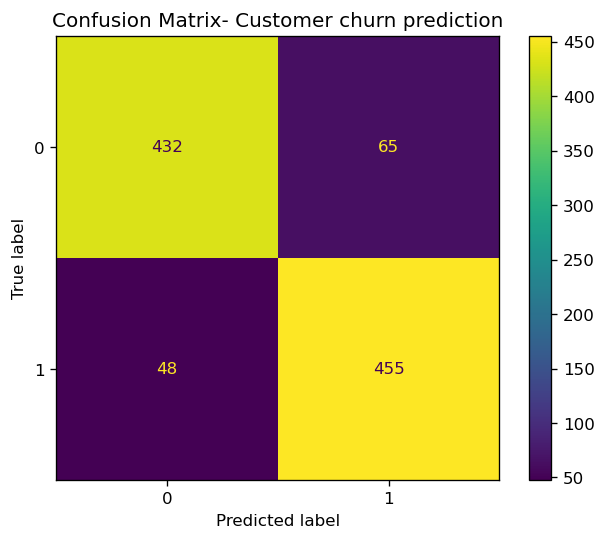

In [32]:
cm=confusion_matrix(y_test, predictions)
figure=ConfusionMatrixDisplay(confusion_matrix=cm)
figure.plot()
plt.title("Confusion Matrix- Customer churn prediction")
plt.show()

ROC Curve and ROC-AUC

In [33]:
y_probability=model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds= roc_curve(y_test, y_probability)
roc_auc= roc_auc_score(y_test, y_probability)
print(f"ROC-AUC: {roc_auc: .3f}")

ROC-AUC:  0.966


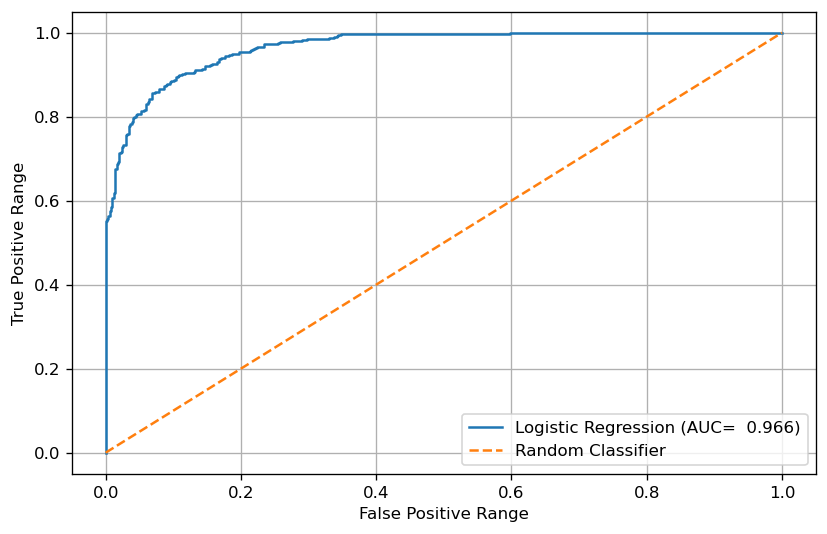

In [34]:
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC= {roc_auc: .3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Range")
plt.ylabel("True Positive Range")
plt.legend()
plt.grid(True)
plt.show()

The ROC curve shows that the model can distinguish between churned and non-churned customers. A higher ROC-AUC indicates better classification performance.

Confusion matrix

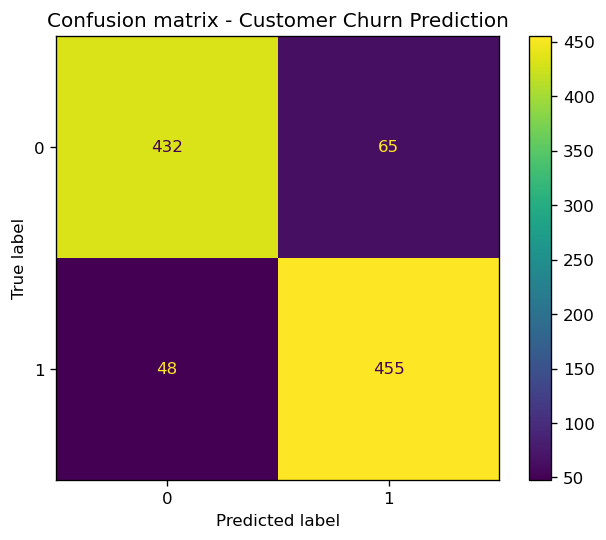

In [35]:
cm=confusion_matrix(y_test, predictions)
display= ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.title("Confusion matrix - Customer Churn Prediction")
plt.show()

## Conclusion:

This project successfully developed a machine learning workflow for predicting customer churn. Exploratory analysis helped identify important customer behavior and engagement patterns, while preprocessing and Logistic Regression provided a reliable classification model. The model achieved 88.70% accuracy, 88.95% F1-score, and 0.966 ROC-AUC, showing strong performance in distinguishing between churned and non-churned customers. Overall, the project demonstrates how customer data can be analyzed and used to support data-driven churn prediction and customer retention strategies.